In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

FigureTitle="Figure"

np.random.seed(1)
if not os.path.exists(FigureTitle):

   # Create a new directory because it does not exist
   os.makedirs(FigureTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

In [3]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1, Remove_exception=True):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    if Remove_exception==True:
        O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




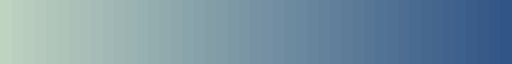

In [4]:
colors = ['#BFD3C1', '#6BA3D0', '#315587']
# Create a custom colormap with 45 distinct shades by interpolating between the base colors
color_list = [colors[0]]
num_steps = 90  # 45 distinct colors, minus the two base colors
for i in range(num_steps):
    r = (i + 1) / (num_steps + 1)
    interpolated_color = [
        int((1 - r) * int(colors[0][j:j+2], 16) + r * int(colors[2][j:j+2], 16))
        for j in (1, 3, 5)
    ]
    interpolated_color = "#{:02X}{:02X}{:02X}".format(*interpolated_color)
    color_list.append(interpolated_color)
color_list.append(colors[2])

cmap_1 = LinearSegmentedColormap.from_list('custom', color_list, N=45)
cmap_1

colors = ['#FF0000', '#FF7F7F', '#FFC0C0'][::-1]

# Create a custom colormap with 45 distinct shades of red by interpolating between the base colors
color_list = [colors[0]]
num_steps = 45 - 2  # 45 distinct colors, minus the two base colors
for i in range(num_steps):
    r = (i + 1) / (num_steps + 1)
    interpolated_color = [
        int((1 - r) * int(colors[0][j:j+2], 16) + r * int(colors[2][j:j+2], 16))
        for j in (1, 3, 5)
    ]
    interpolated_color = "#{:02X}{:02X}{:02X}".format(*interpolated_color)
    color_list.append(interpolated_color)
color_list.append(colors[2])

cmap_2 = LinearSegmentedColormap.from_list('custom', color_list, N=45)
cmap_1

In [5]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


def metric5(u,v,m):
    return SimilarityJS(u,m), SimilarityJS(v,m)

def metric6(u,v,m):
    return SimilarityJS(u,m,1e-4), SimilarityJS(v,m,1e-4)


def metric7(u,v,m):
    return np.sum(np.minimum(u,m))/np.sum(np.maximum(u,m)), np.sum(np.minimum(v,m))/np.sum(np.maximum(v,m))


In [6]:

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

def mask_equal(u,v,m):
    u_m=np.array(u)>0
    v_m=np.array(v)>0
    shared=u_m*v_m
    mask1=u_m-shared*(np.array(v)/(np.array(u)+np.array(v)+1e-8))
    mask2=1-mask1
    return mask1, mask2

def NbyNcomposition(Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    Coal_matrix={}
    Coal_keys={}
    Coal_mask1={}
    Coal_mask2={}
    Sub_keys={}
    Sub_matrix={}
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        subSampleIDX1=np.where(Sub_IDX_list==subSampleIDX1)[0][0]
        subSampleIDX2=np.where(Sub_IDX_list==subSampleIDX2)[0][0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_mix=df.values[1:].tolist()
        ID_mix=df.values[0]
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_1=df.values[1:].tolist()
        ID_1=df.values[0]   
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_2=df.values[1:].tolist()
        ID_2=df.values[0]          
        
        mask_1,mask_2=mask_equal(c_1,c_2,c_mix)
        
        
        i=min(subSampleIDX1,subSampleIDX2)
        j=max(subSampleIDX1,subSampleIDX2)
        Coal_matrix[i,j]=c_mix
        Coal_keys[i,j]=ID_mix
        Coal_mask1[i,j]=mask_1
        Coal_mask2[i,j]=mask_2
        
        
    for SampleIDX in Sub_IDX_list:
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        i=np.where(Sub_IDX_list==SampleIDX)[0][0]
        Sub_matrix[i]=df.values[1:].tolist()
        Sub_keys[i]=df.values[0]
        
    return Coal_matrix, Sub_matrix, Coal_keys, Sub_keys,Coal_mask1,Coal_mask2



########################################################
########################################################
# Fig 1-2
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

########################################################
########################################################
# Fig 1-3
########################################################
########################################################


In [7]:
-5*(-5>0)

0

In [8]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


def PolarizedPlot(data1,data2):
        colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        ax.scatter(data1,data2, s=25,color=colors[c_i], marker='.', alpha=0.7,linewidths=0)
        ax.scatter(data2,data1, s=25,color='grey', marker='.', alpha=0.2,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        #plt.xlabel('to C1')
        #plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        return f
    
def TriangularPlot(data1,data2):
    colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]
    
    data1=np.array(data1)
    data2=np.array(data2)
    fig, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
    i2=data1**2; i3=data2**2; i1=1-data1**2-data2**2; ## example of defining the fractions of species 1, 2, and 3
    iy = i1*(3**0.5); # y coordinate in simplex plot, where top=1, bottom left=2, bottom right=3
    ix = (i3-i2); # x coordinate in simplex plot
    ax.scatter( ix, iy , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)
    
    ax.scatter(iy,ix, s=30,color='grey', marker='.', alpha=0.5,linewidths=0)

    p1=[1, 0]
    p2=[-1, 0]
    p3=[0, np.sqrt(3)]
    ax.plot([1, -1], [0, 0] , linewidth= 0.8, c= 'black')
    ax.plot([1, 0], [0, np.sqrt(3)] , linewidth= .8, c= 'black')
    ax.plot([-1, 0], [0, np.sqrt(3)] , linewidth= .8, c= 'black')

    ax.set_xlim(-1.1,1.1);
    ax.set_ylim(-0.2,2.);
    plt.gca().set_axis_off()
    return fig




def AsyPrePlot(data1,data2):
        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        data1=np.array(data1)
        data2=np.array(data2)
        x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
        y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
        print(type_name,np.mean(x*y), np.std(x*y))
        y=x*y
        #print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

        ax.scatter(x, y , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0,  xmin=0.05, xmax=1, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, ymin=0, ymax=0.95, color='k', linestyle='--', linewidth=.5)
        plt.axhline(-0.05, color='k', linestyle='-', linewidth=.5)
        plt.axvline(1.05, color='k', linestyle='-', linewidth=.5)

        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        return f
        
def HalfFoldedPolarizedPlot(data1,data2):
        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        data1=np.array(data1)
        data2=np.array(data2)
        x=np.maximum(data1,data2)
        y=np.minimum(data1,data2)

        ax.scatter(x, y , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y

        R = np.sqrt(abs(X**2 + Y**2))*floor(X>Y)
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
        
        

        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0,  xmin=0.05, xmax=1, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, ymin=0, ymax=0.95, color='k', linestyle='--', linewidth=.5)
        plt.axhline(-0.05, color='k', linestyle='-', linewidth=.5)
        plt.axvline(1.05, color='k', linestyle='-', linewidth=.5)

        #plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([])
                # Define the grid of points

        return f




In [9]:
from scipy.stats import gaussian_kde

def thetaplot(data1, data2, color='blue', smoothing=0.1):
    """
    Plots a smoothed histogram of θ = arctan(data1/data2), limited to the range -π/4 to π/4, with shading under the smoothed line.

    Parameters:
        data1, data2: Lists or arrays of data points to compute θ
        color: Color of the histogram bars and KDE curve (default is blue)
        smoothing: Bandwidth for the KDE smoothing (default is 0.2)

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    
    # Calculate theta using arctan2 and restrict to [-π/4, π/4]
    theta = np.arctan2(data1, data2) - np.pi/4
    theta = np.append(theta,-theta)    #theta = theta[(theta >= -np.pi/4) & (theta <= np.pi/4)]
    
    # Create figure
    f, ax = plt.subplots(figsize=(60*mm,30*mm))
    
    # KDE for smoothing
    kde = gaussian_kde(theta, bw_method=smoothing)
    theta_vals = np.linspace(-np.pi/4, np.pi/4, 500)
    kde_vals = kde(theta_vals)
    
    # Plot the KDE line
    #ax.plot(theta_vals, kde_vals, color=colors[c_i], linewidth=1, label='Smoothed Density')
    ax.hist(theta, bins=20, range=(-np.pi/4, np.pi/4), color=colors[c_i], alpha=0.5, edgecolor='white', density=True)
    # Shade area under the KDE line
    ax.fill_between(theta_vals, kde_vals, color=colors[c_i], alpha=0.3)
    
    # Set labels and title
    #ax.set_xlabel(r'$\theta = \arctan\left(\frac{\mathrm{data1}}{\mathrm{data2}}\right)$')
    #ax.set_ylabel('Count')
    #ax.set_title('Histogram of θ with Smoothing and Shaded Area')
    
    # Set x-axis limits and ticks
    ax.set_xlim(-np.pi/4, np.pi/4)
    ax.set_ylim(0, 4.5)

    ax.set_xticks([-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4])
    ax.set_xticklabels([r'$-\frac{\pi}{4}$', r'$-\frac{\pi}{8}$', '0', r'$\frac{\pi}{8}$', r'$\frac{\pi}{4}$'])
    
    plt.tight_layout()
    
    return f

def rplot(data1, data2, color='blue', smoothing=0.1):
    """
    Plots a smoothed histogram of r = sqrt(data1**2 + data2**2) with shading under the smoothed line.

    Parameters:
        data1, data2: Lists or arrays of data points to compute r
        color: Color of the histogram bars and KDE curve (default is blue)
        smoothing: Bandwidth for the KDE smoothing (default is 0.1)

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    
    # Calculate r as the Euclidean distance
    r = np.sqrt(np.array(data1)**2 + np.array(data2)**2)
    
    # Create figure
    f, ax = plt.subplots(figsize=(60*mm,30*mm))
    
    # KDE for smoothing
    kde = gaussian_kde(r, bw_method=smoothing)
    r_vals = np.linspace(r.min(), r.max(), 500)
    kde_vals = kde(r_vals)
    
    # Plot the KDE line
    #ax.plot(r_vals, kde_vals, color=colors[c_i], linewidth=1.5, label='Smoothed Density')
    
    # Plot histogram with white edges on bars
    ax.hist(r, bins=20, color=colors[c_i], alpha=0.5, edgecolor='white', density=True)
    
    # Shade area under the KDE line
    ax.fill_between(r_vals, kde_vals, color=colors[c_i], alpha=0.3)
    
    # Set labels and title
    #ax.set_xlabel(r'$r = \sqrt{\mathrm{data1}^2 + \mathrm{data2}^2}$')
    #ax.set_ylabel('Density')
    #ax.set_title('Histogram of r with Smoothing and Shaded Area')
    
    # Set x-axis limits based on range of r
    ax.set_xlim(0, 1)
    
    plt.tight_layout()
    
    return f




LN_12
0.6976828701638894 0.6507093531495102 0.2996930936868971
48 P4-59
52
47
HN_12
0.6551941108594913 0.7033524777060595 0.27570993670846855
2 P6-64
HN_12
0.6277708955772688 0.6970450796403872 0.34645614385552503
25 P6-81
HN_12
0.6309551692296007 0.7105041134328601 0.3115758001152066
44 P6-26
52


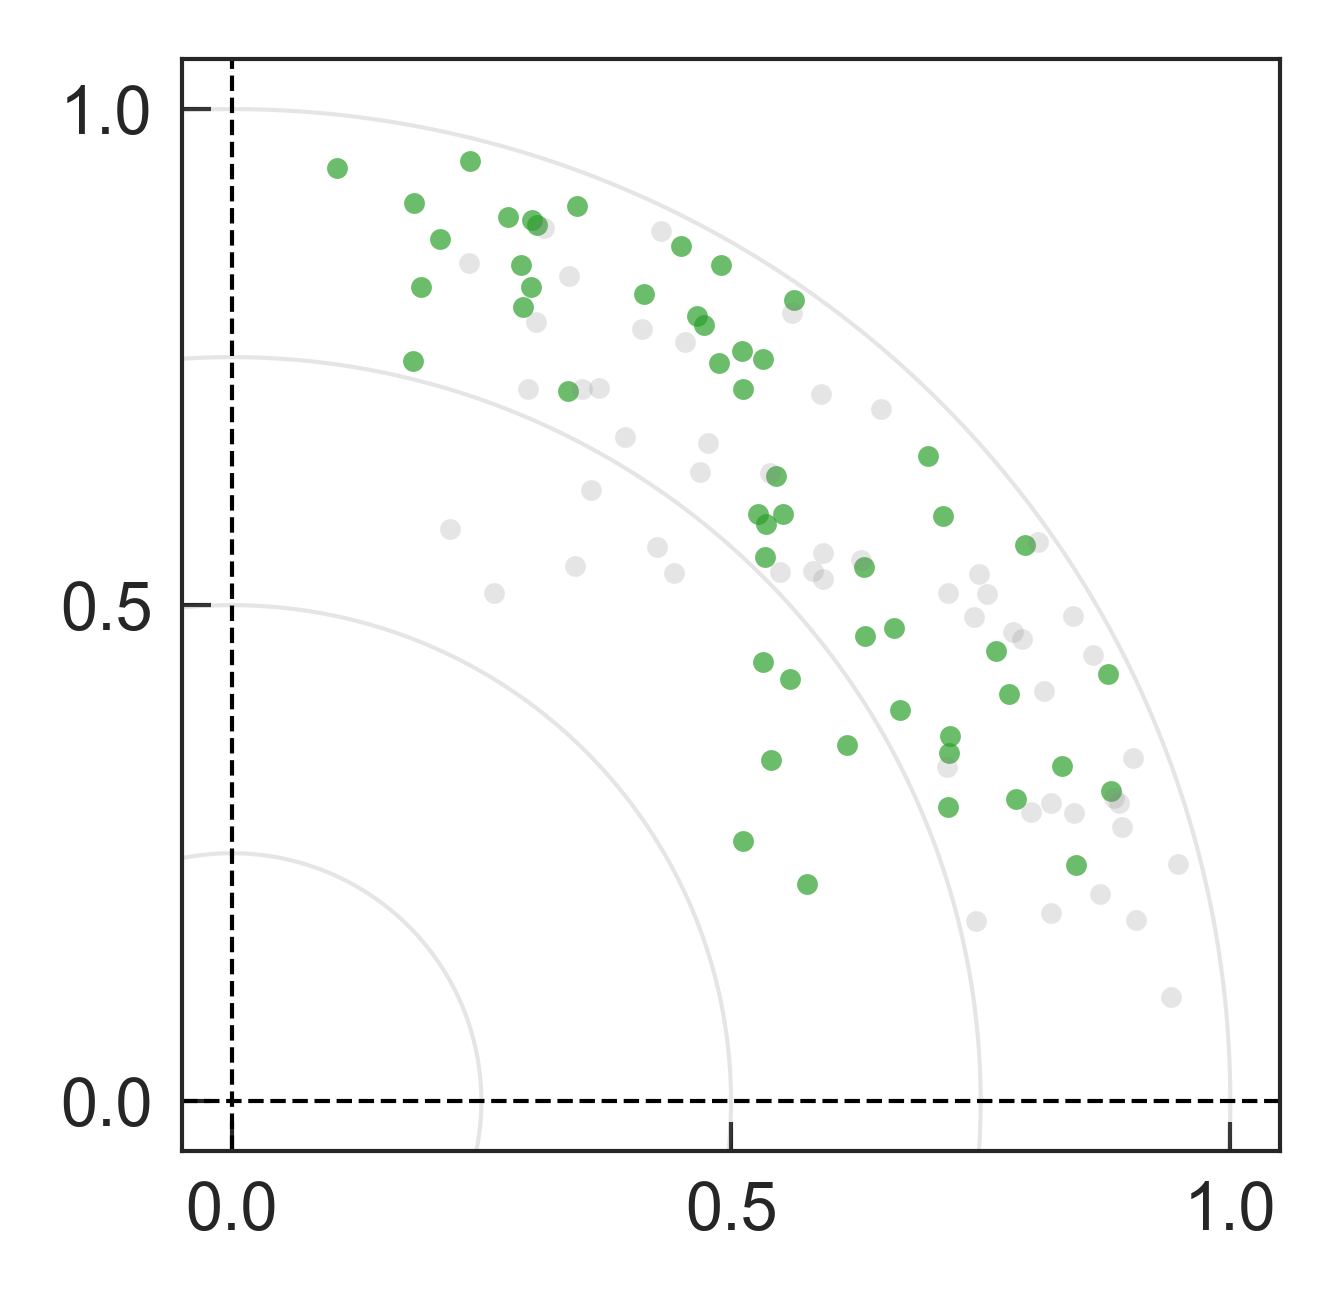

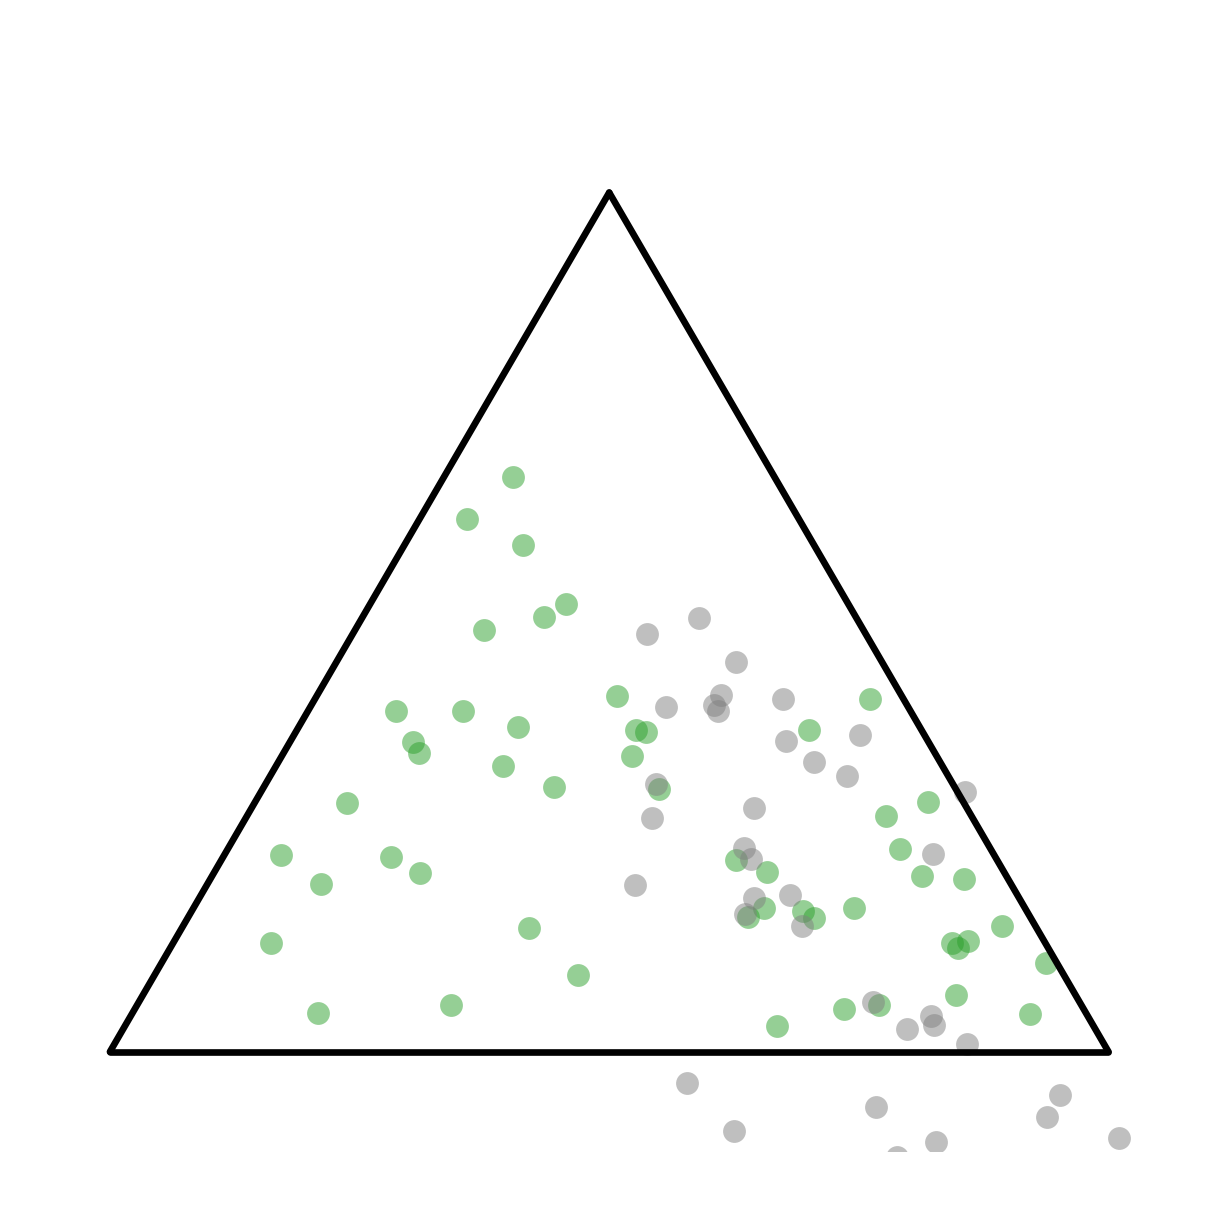

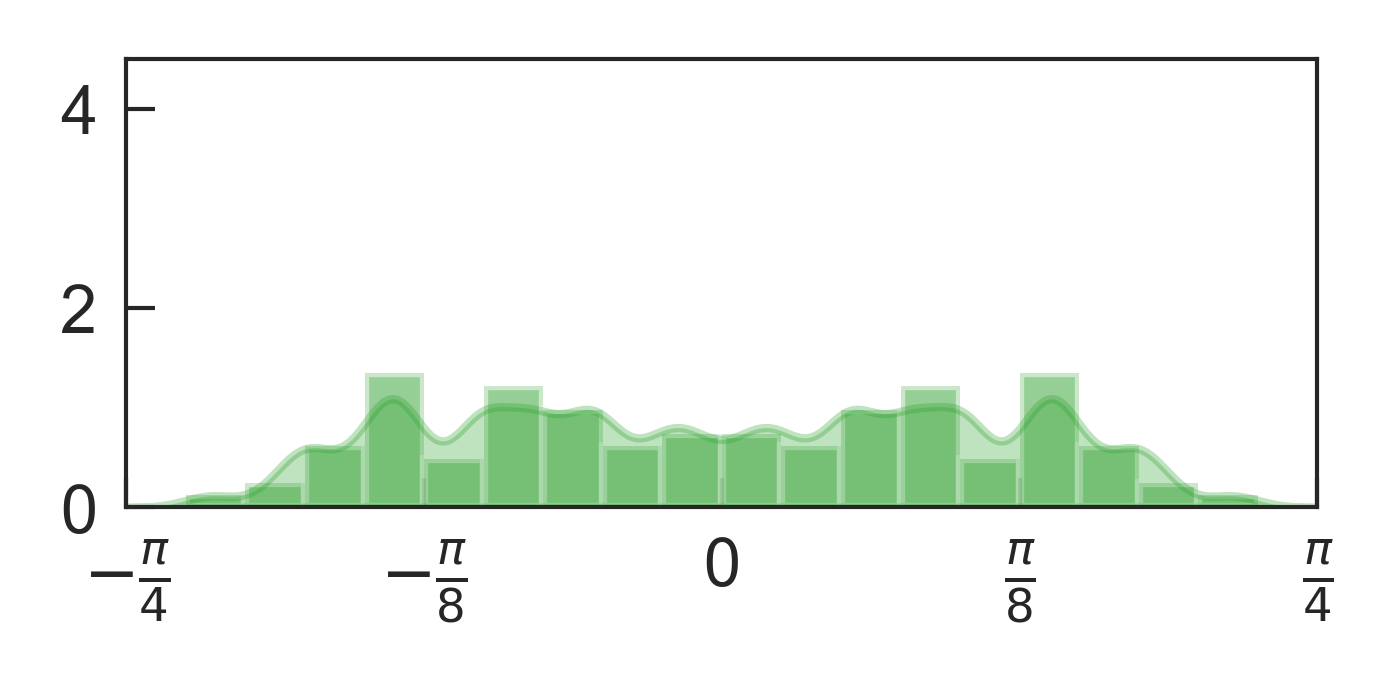

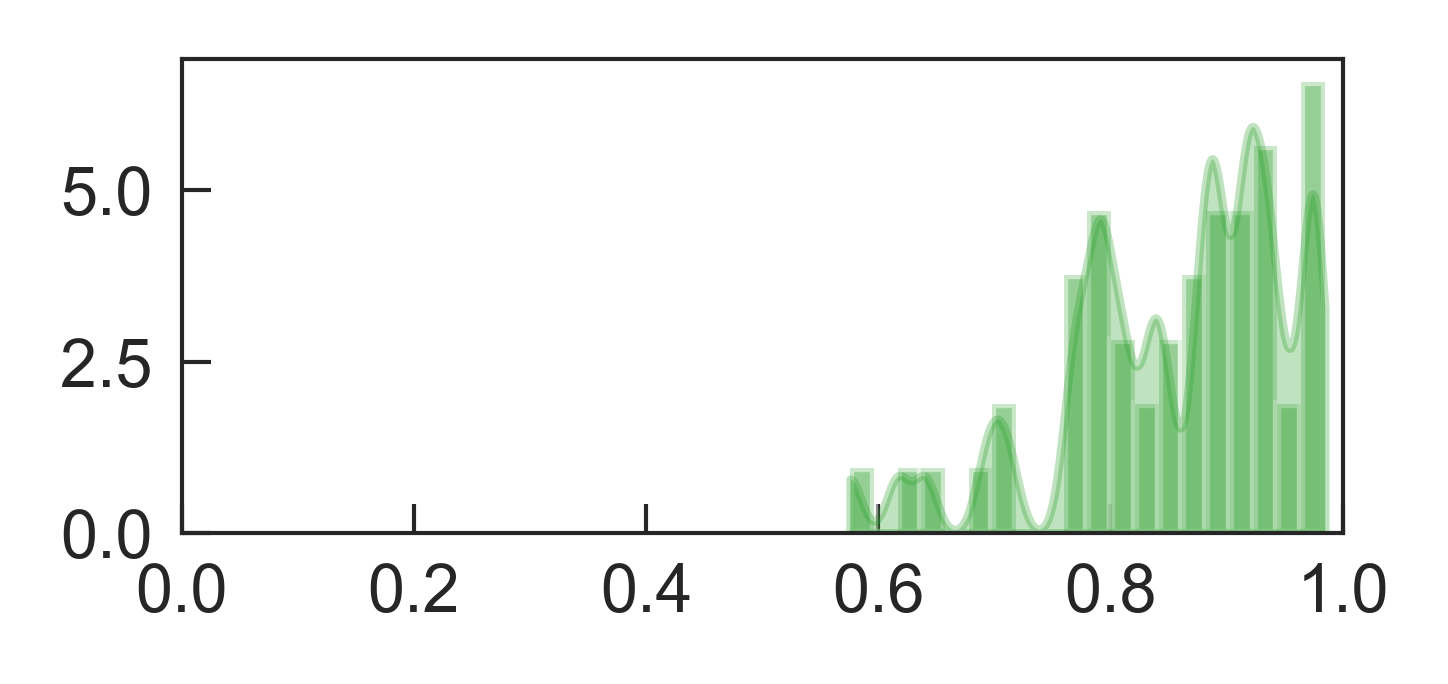

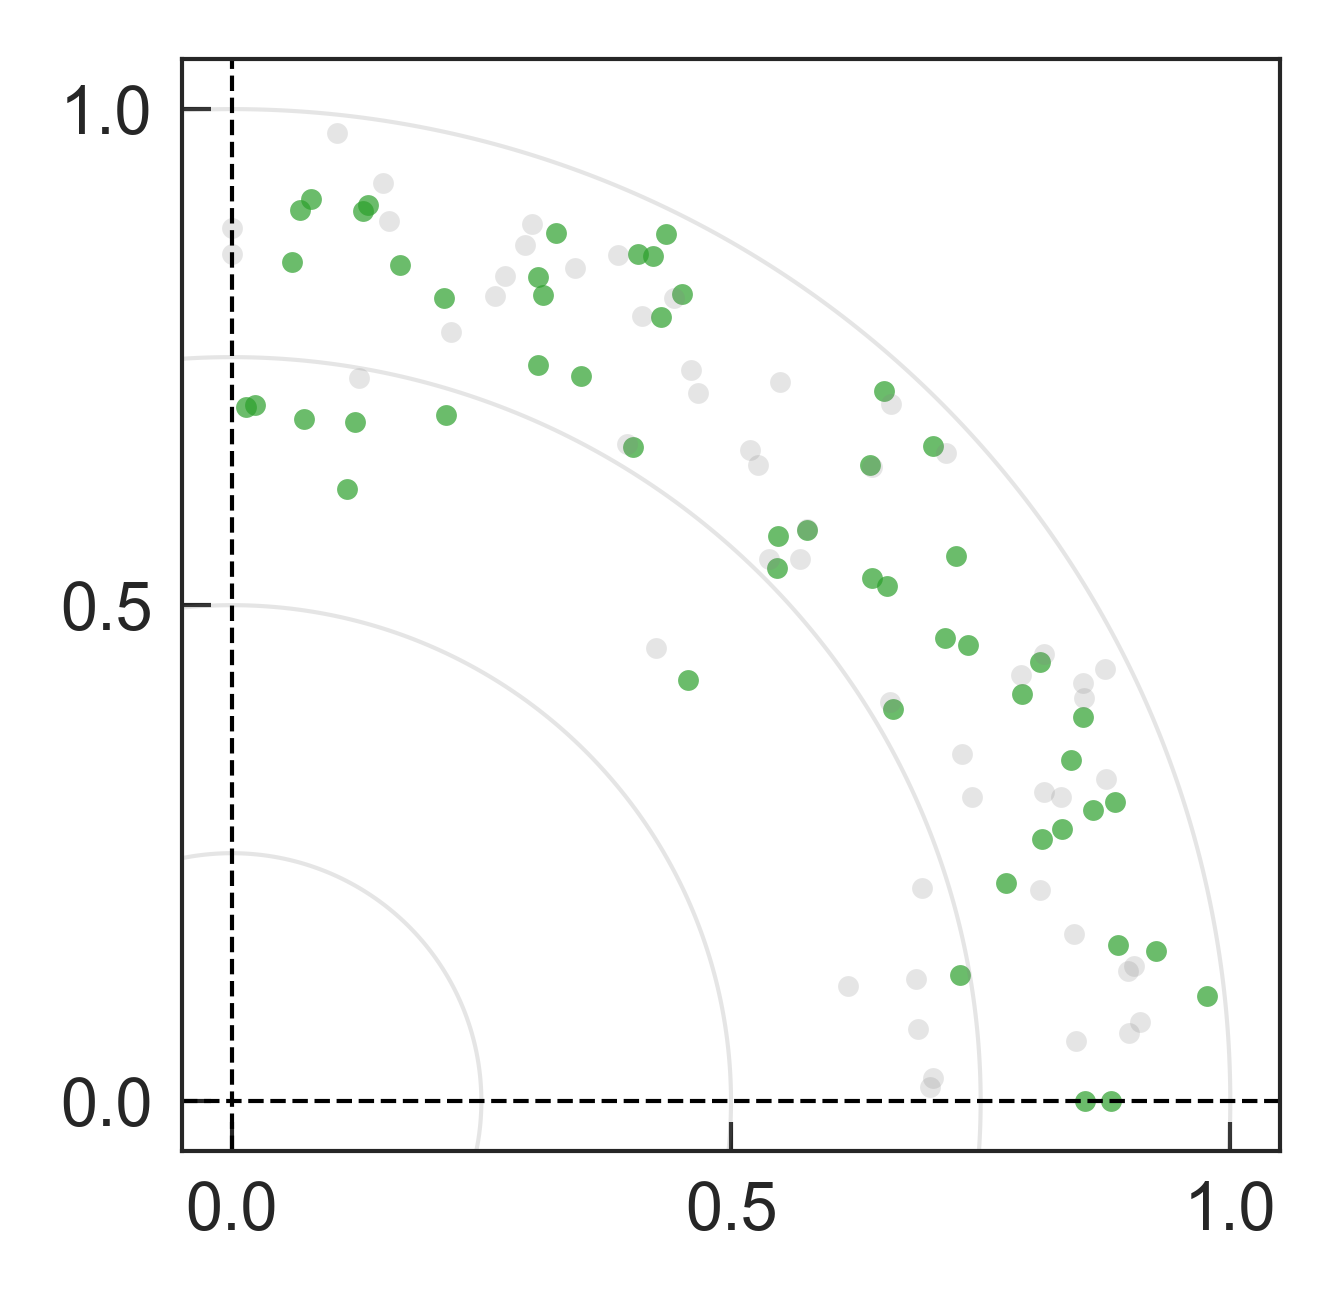

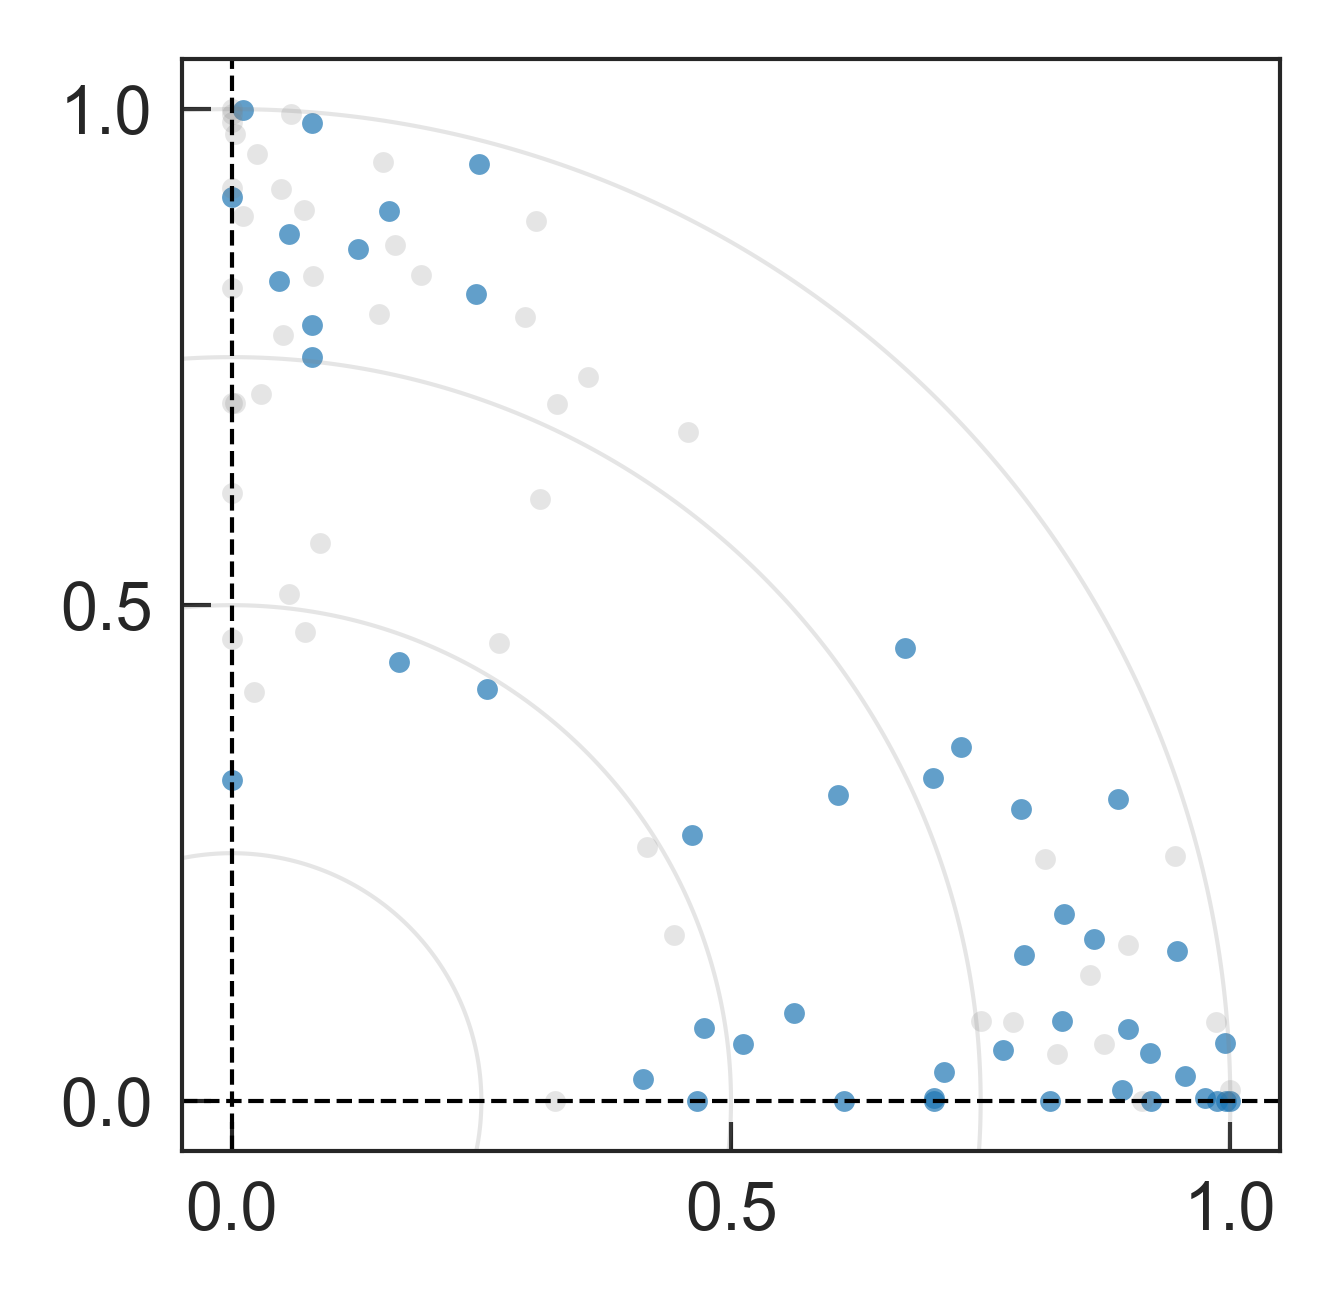

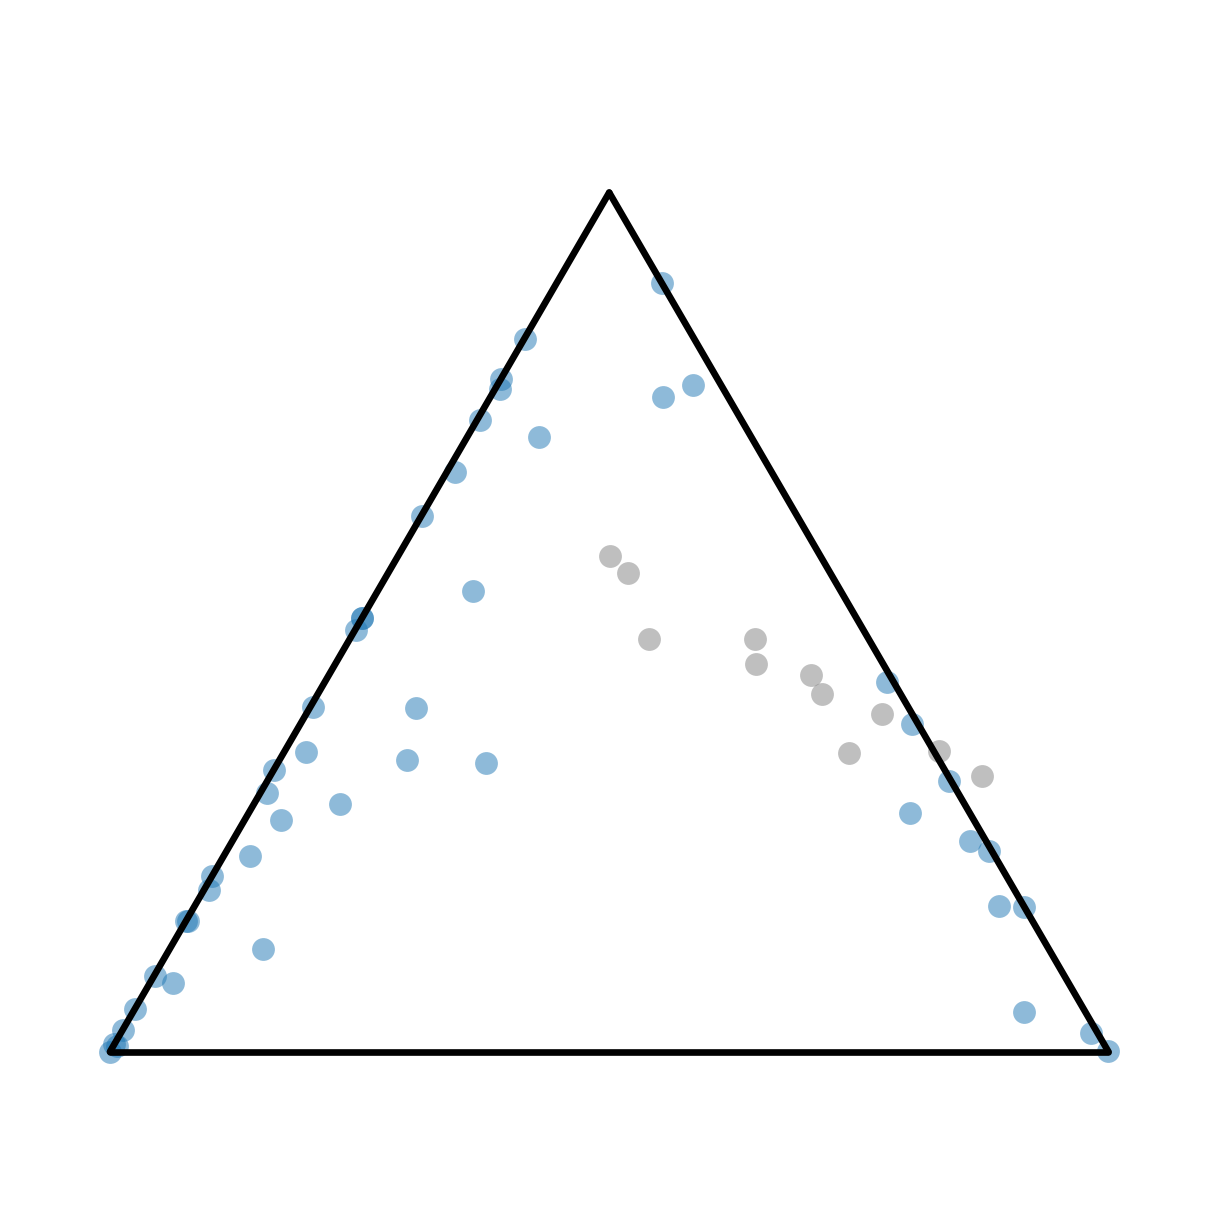

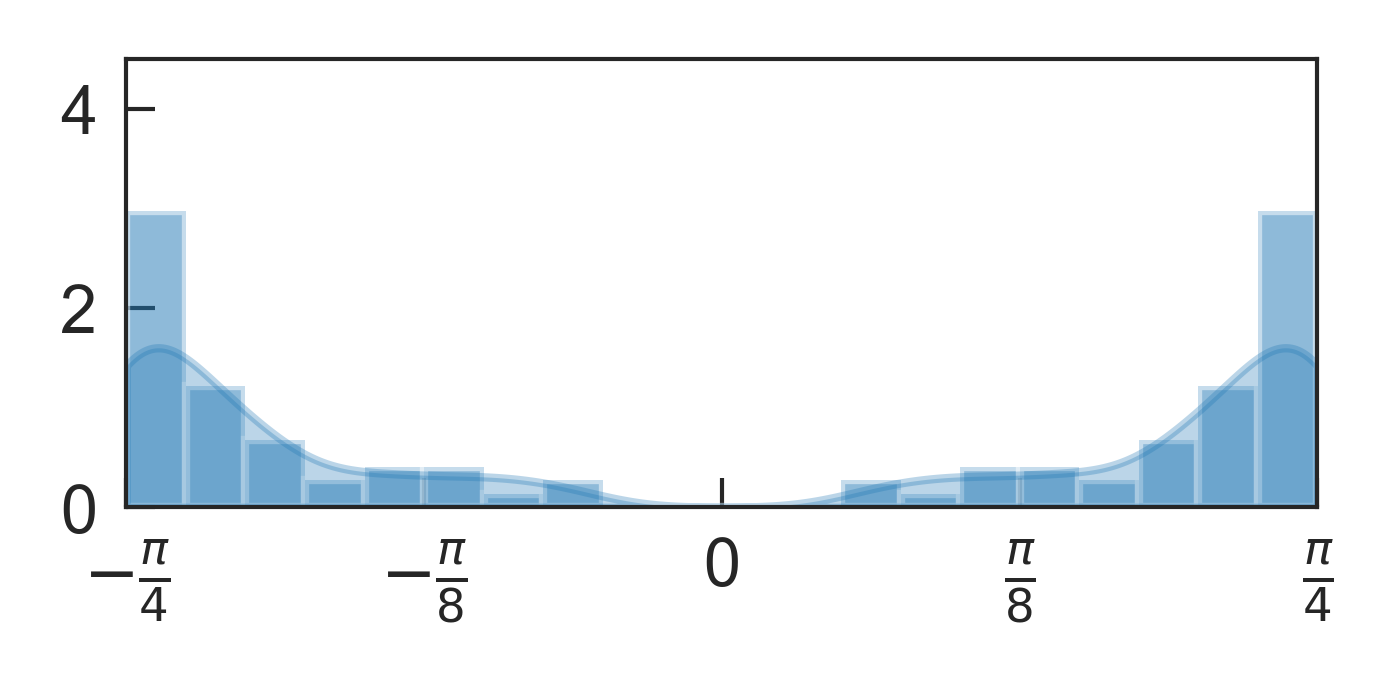

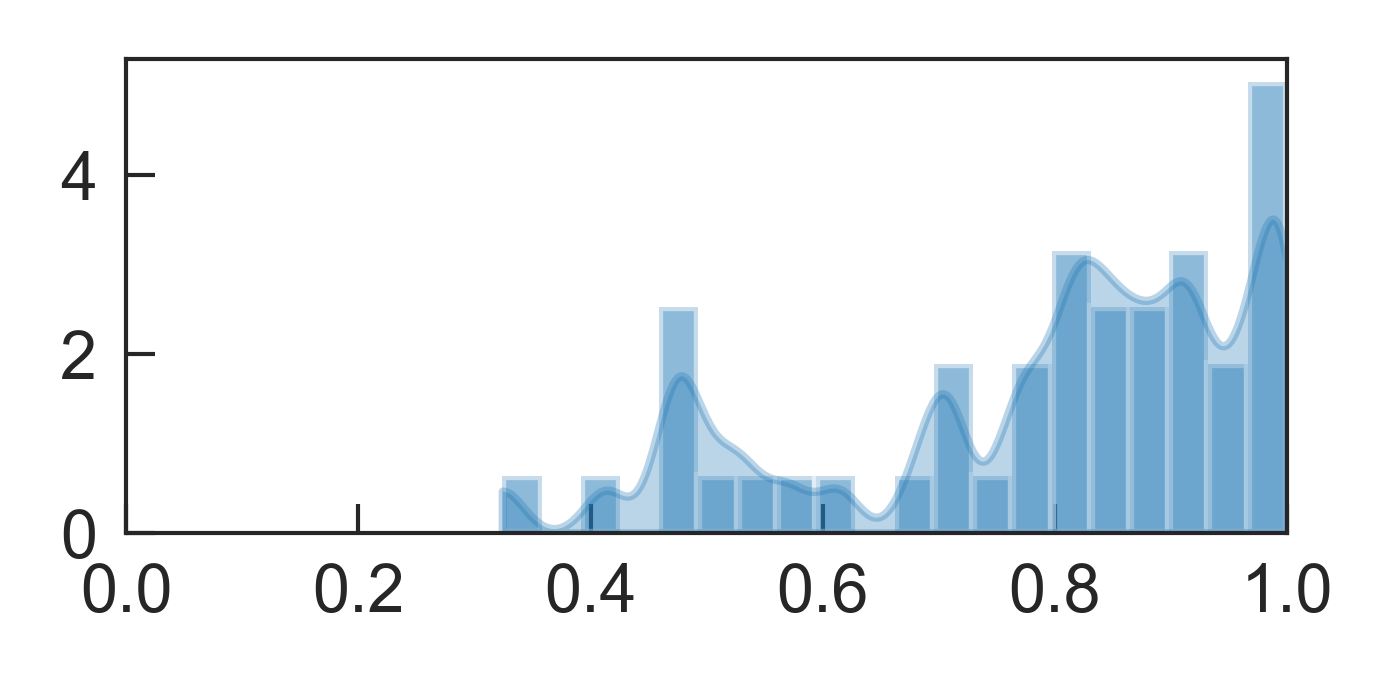

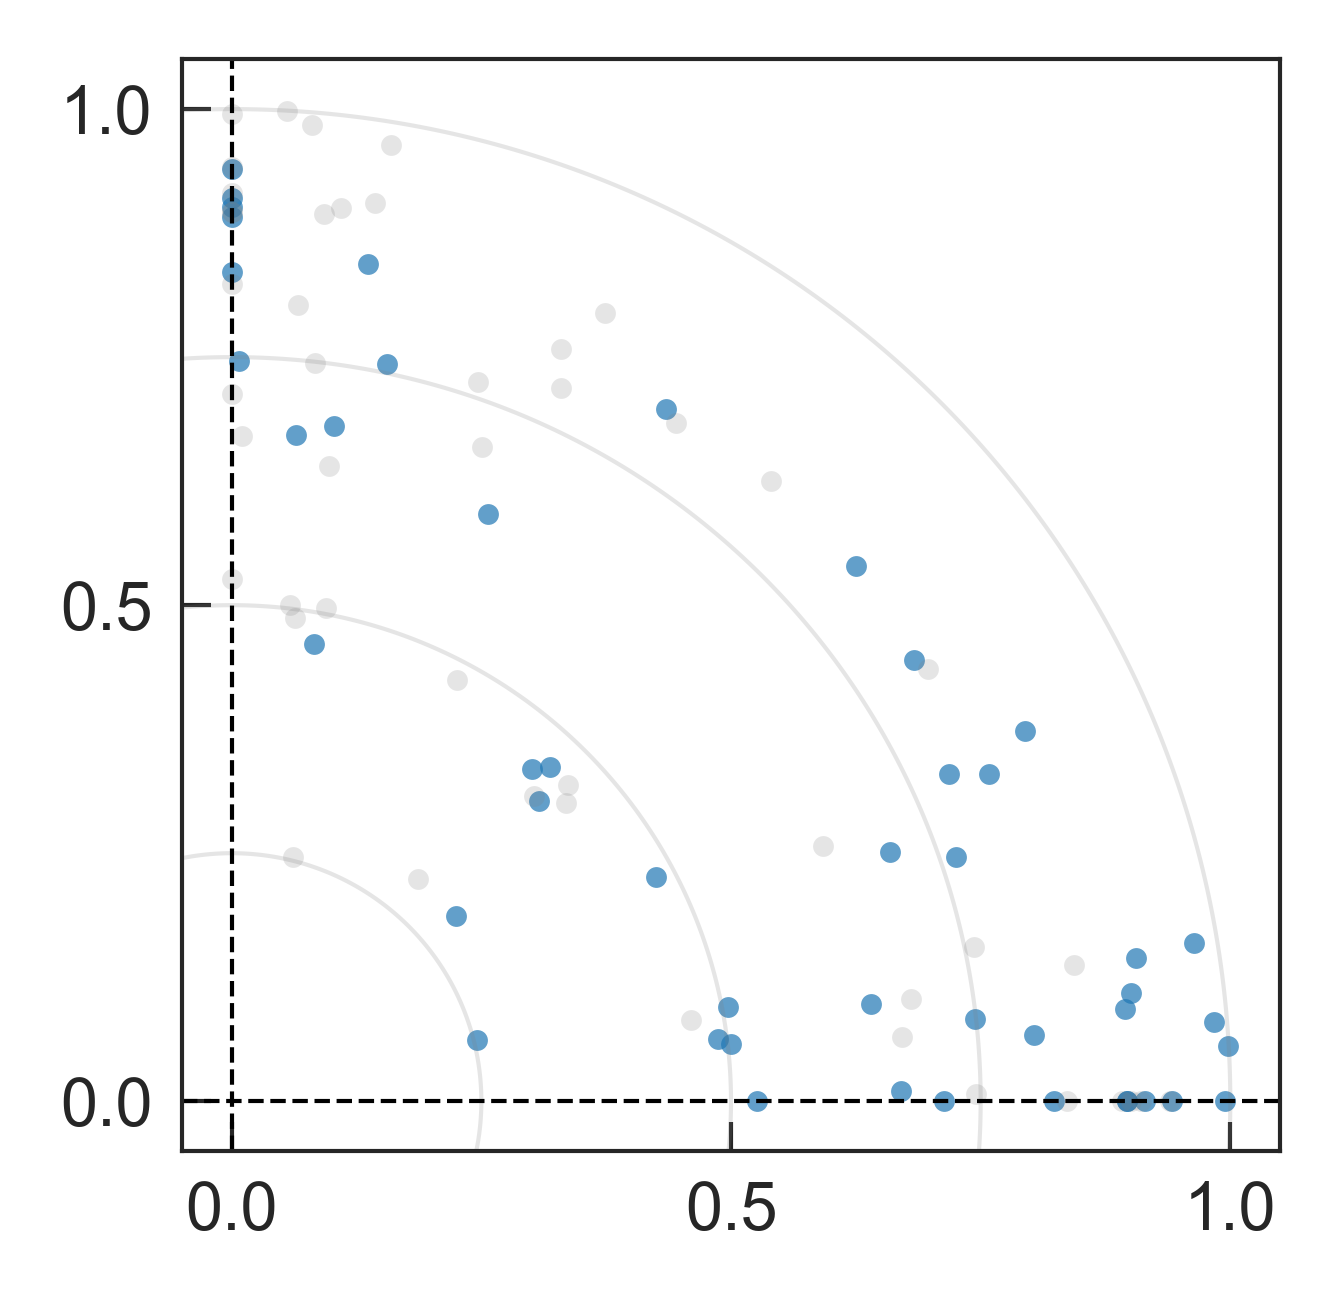

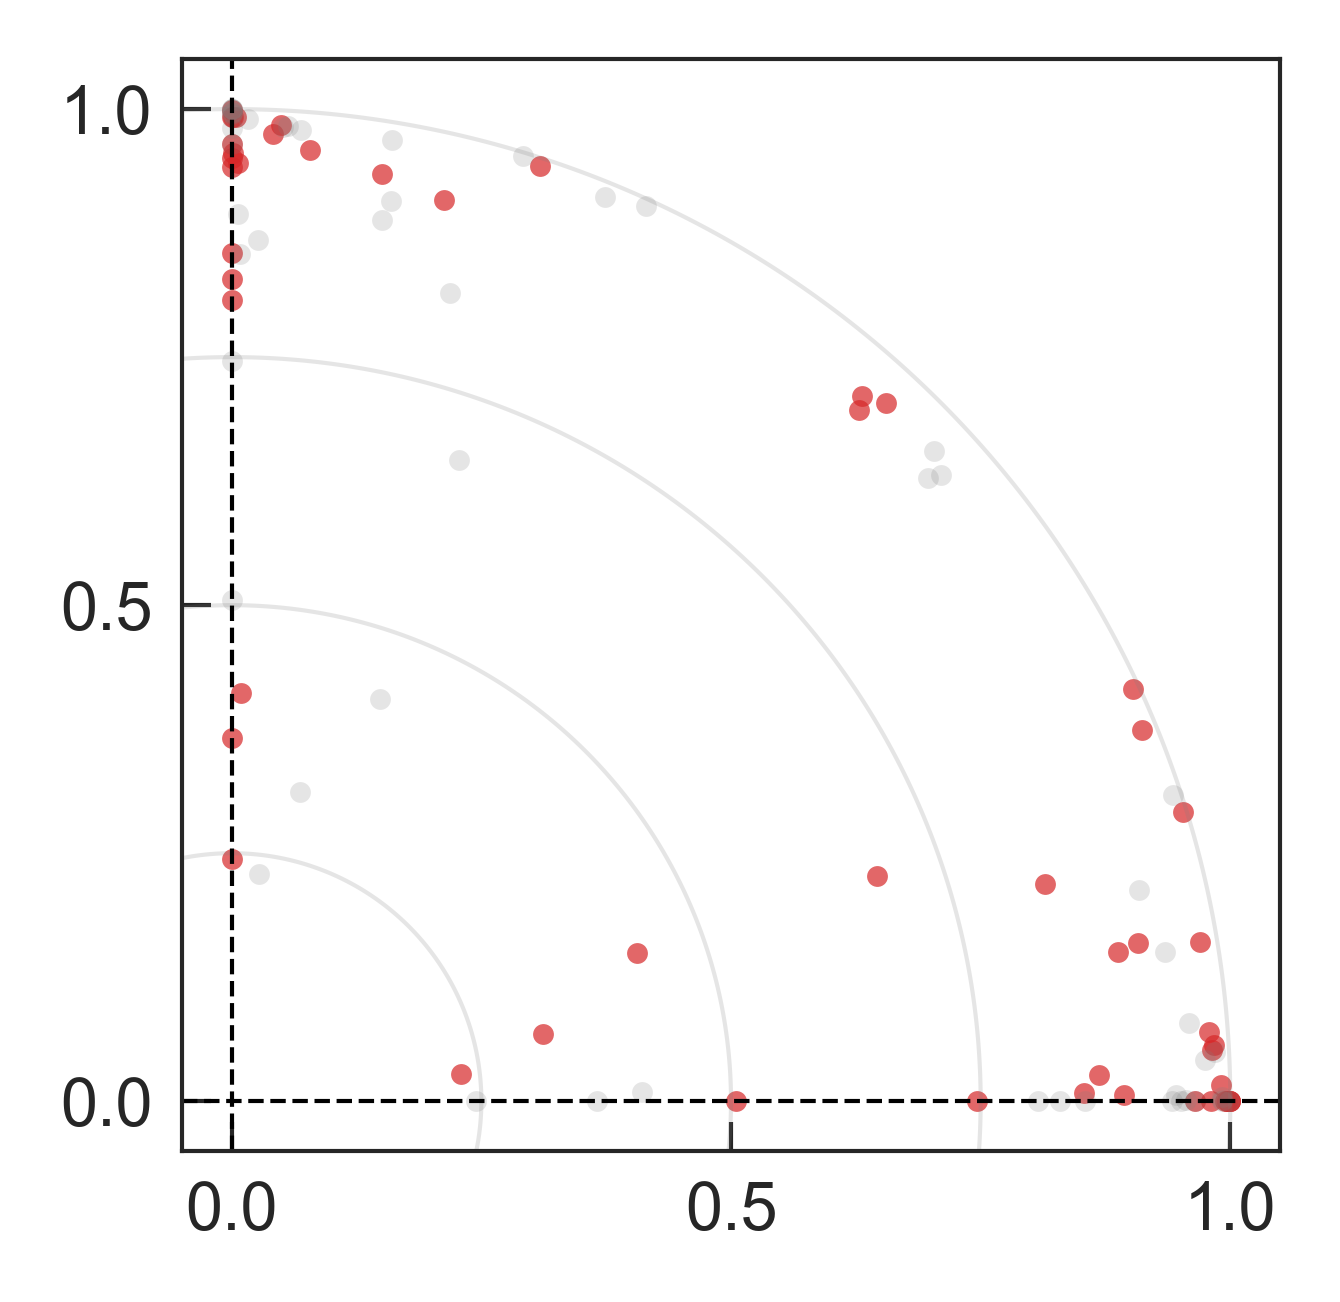

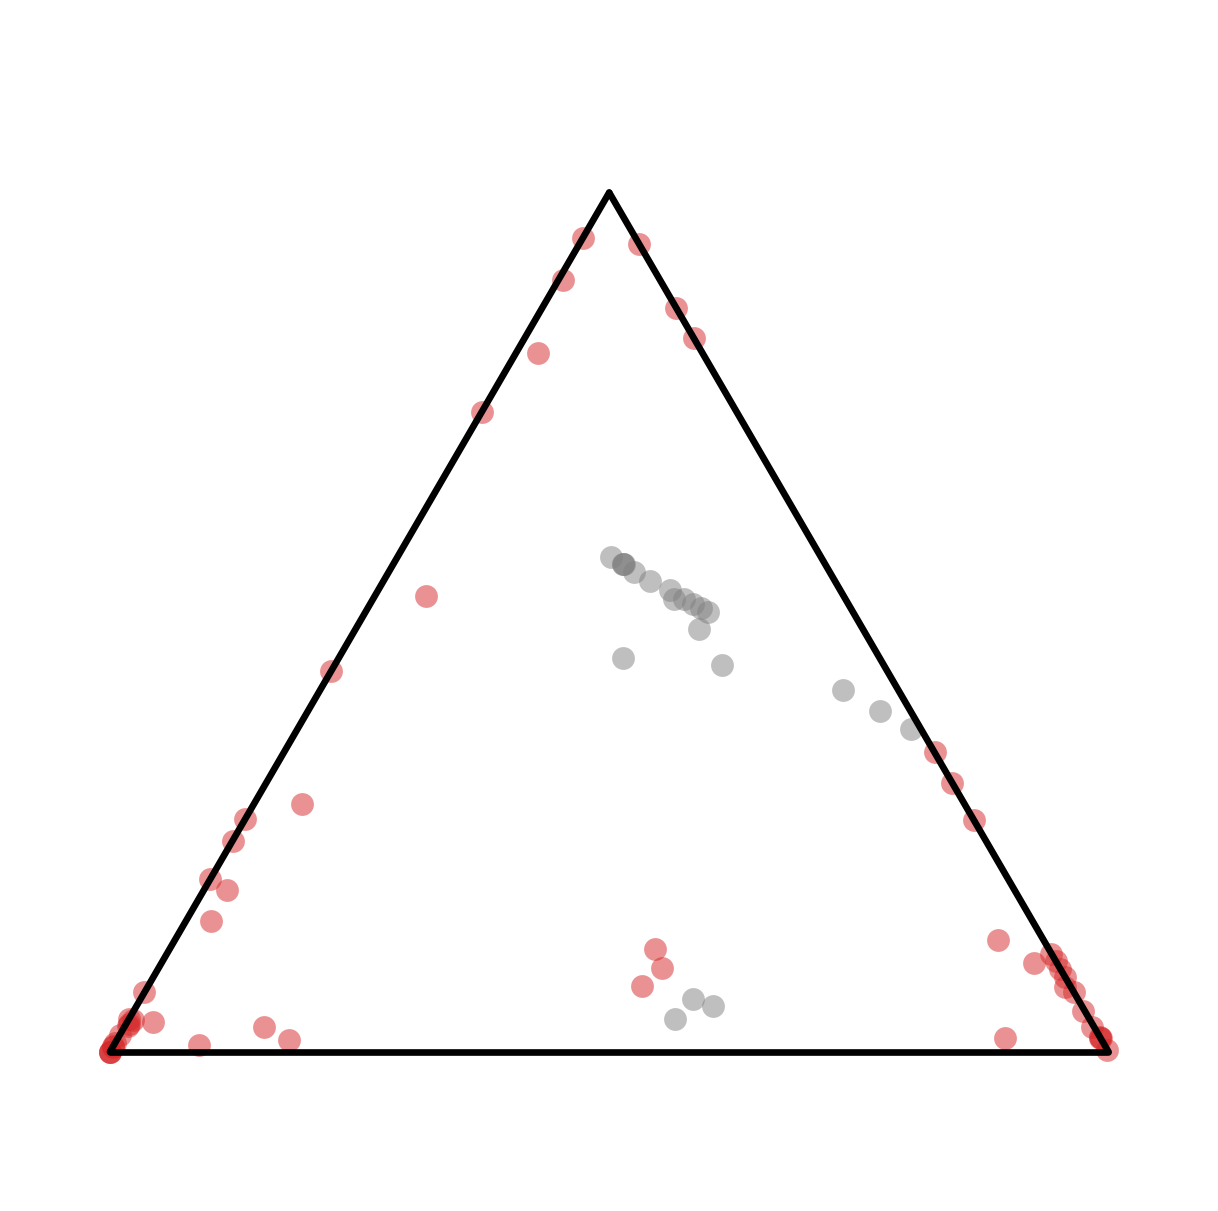

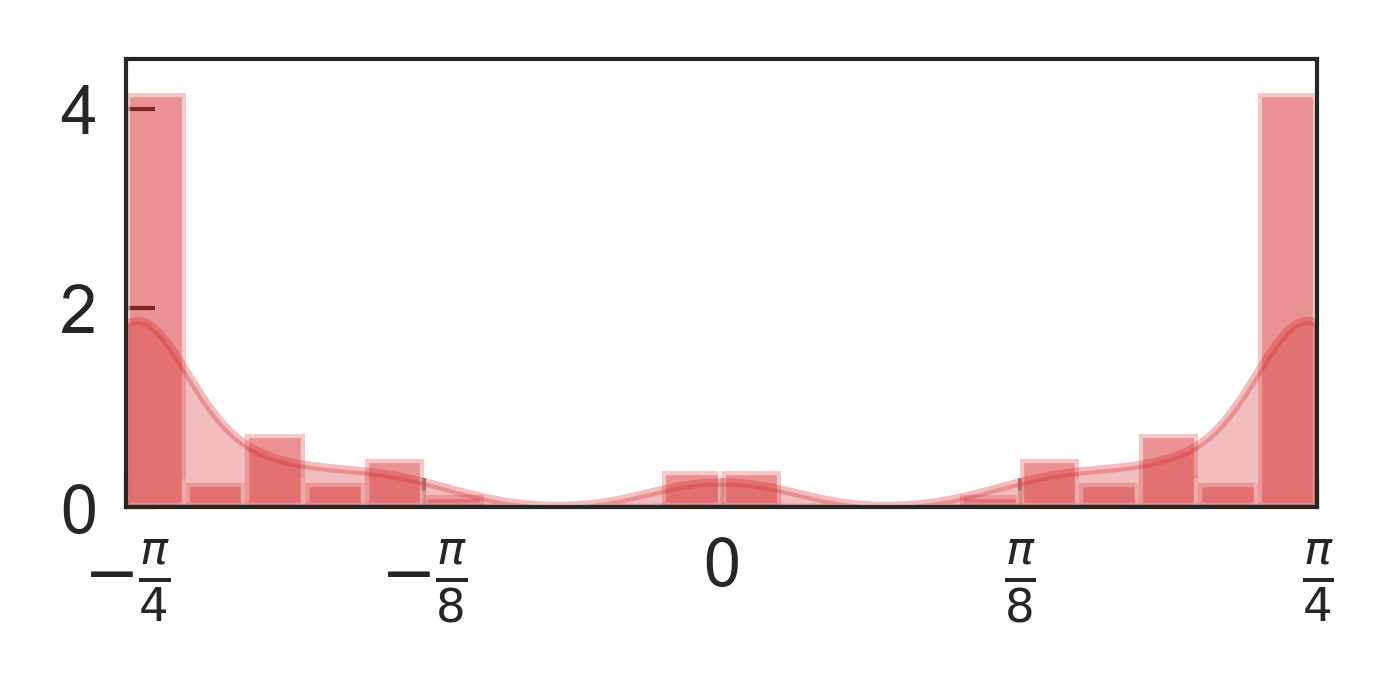

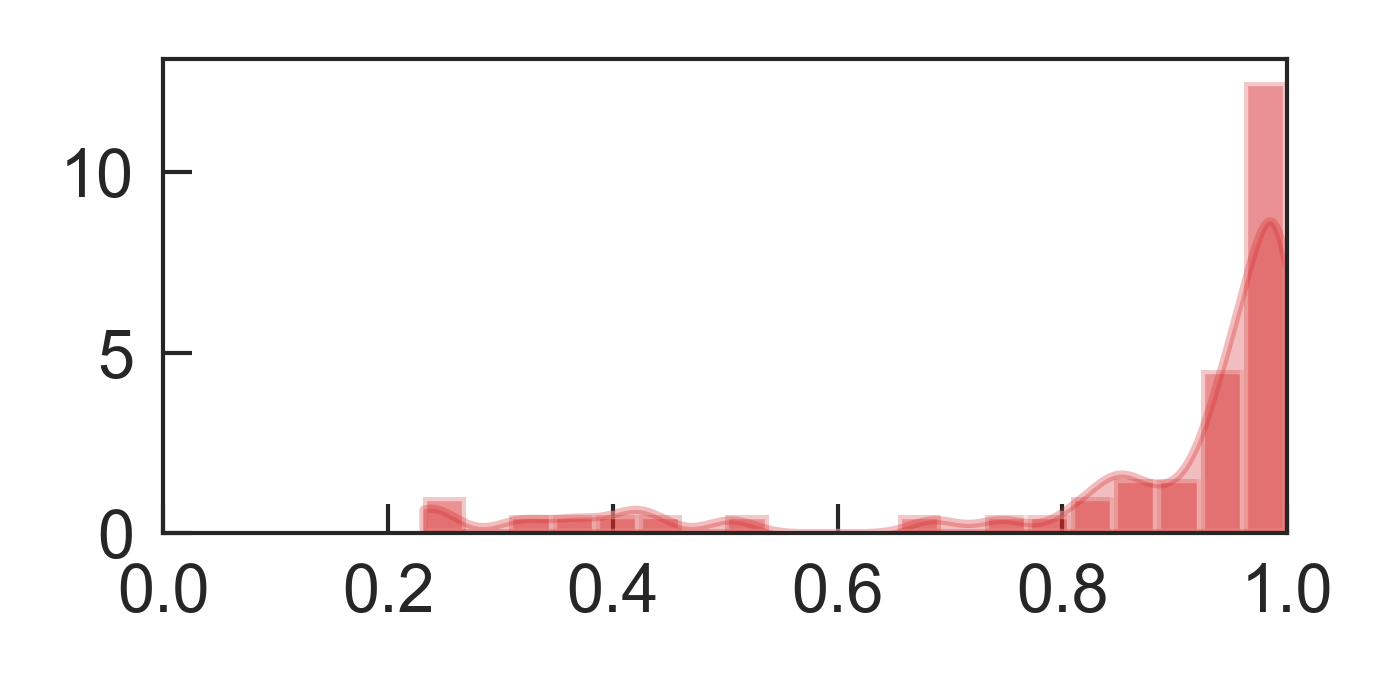

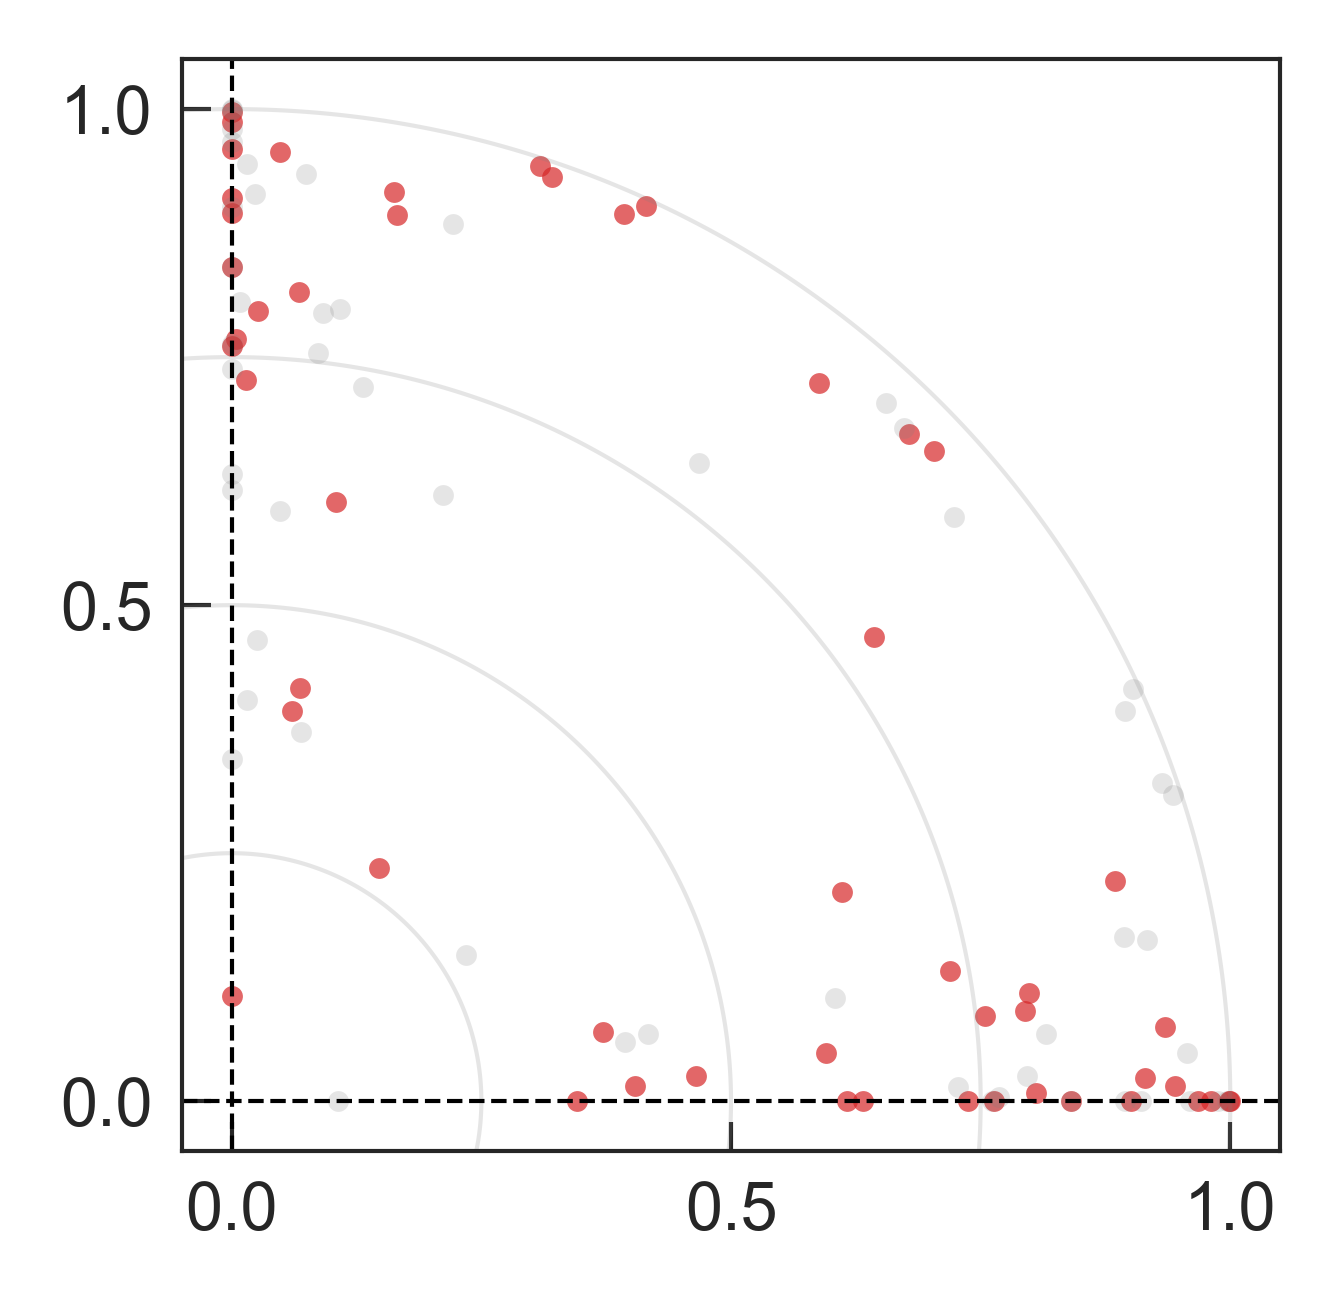

In [10]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' 
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(43)
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):

    Null_model_rep=1



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        IDX_list = Syn_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        data1=[]
        data2=[]
        data3=[]
        data4=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(Null_model_rep):
                c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))
                if _==0:
                    u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
                    #a=abs(u/np.sqrt(u*u+v*v))
                    #b=abs(v/np.sqrt(u*u+v*v))
                    #u=a
                    #v=b
                    data1.append(u)
                    data2.append(v)
                    if u>0.6 and v>0.6:
                        print(type_name)
                        print(u,v,k)
                        print(i, IDX_list[i])
                        #print("y",Processed_sequences_synthetic.iloc[idx[i]][0])
                        #print("ex1",Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[0])
                        #print("ex2",Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[0])
                u,v,k=metric_VectorDecomposition_onlyPositive(moc_c1,moc_c2,c_mix)
                data3.append(u)
                data4.append(v)
                #data_null_model.append(metric2(moc_c1,moc_c2,c_mix))

        data_temp1 = data1+data2
        data_temp2 = data2+data1
        #data1=data_temp1
        #data2=data_temp2
        print(len(data1))
        data_null_model = np.array(data_null_model)
        data_null_model = data_null_model.reshape([-1,Null_model_rep])
        #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

        f=PolarizedPlot(data1,data2)
        #plt.title(f'{type_name}')
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_Polarized.svg',bbox_inches='tight')

        f=TriangularPlot(data1,data2)
        #plt.title(f'{type_name}')
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_Triangular.svg',bbox_inches='tight')

        f=thetaplot(data1, data2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_Theta.svg',bbox_inches='tight')

        f=rplot(data1, data2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_R.svg',bbox_inches='tight')
        #f=AsyPrePlot(data1,data2)
        #f.savefig(f'Figure/Metric_metric3_{type_name}_style_HalfFoldedPolarized.svg',bbox_inches='tight')

        #f= HalfFoldedPolarizedPlot(data1,data2)
        #f.savefig(f'Figure/Metric_metric3_{type_name}_style_HalfFoldedPolarized.svg',bbox_inches='tight')

        f= PolarizedPlot(data3,data4)
        #plt.title(f'{type_name}_Null')
        f.savefig(f'Figure/Metric_metric3_{type_name}_null_style1_Polarized.svg',bbox_inches='tight')






        

LN_12 0.3293594392052075 0.19558321889607427
LN_12 0.724330317507856 0.06295099037038146


AttributeError: 'function' object has no attribute 'clabel'

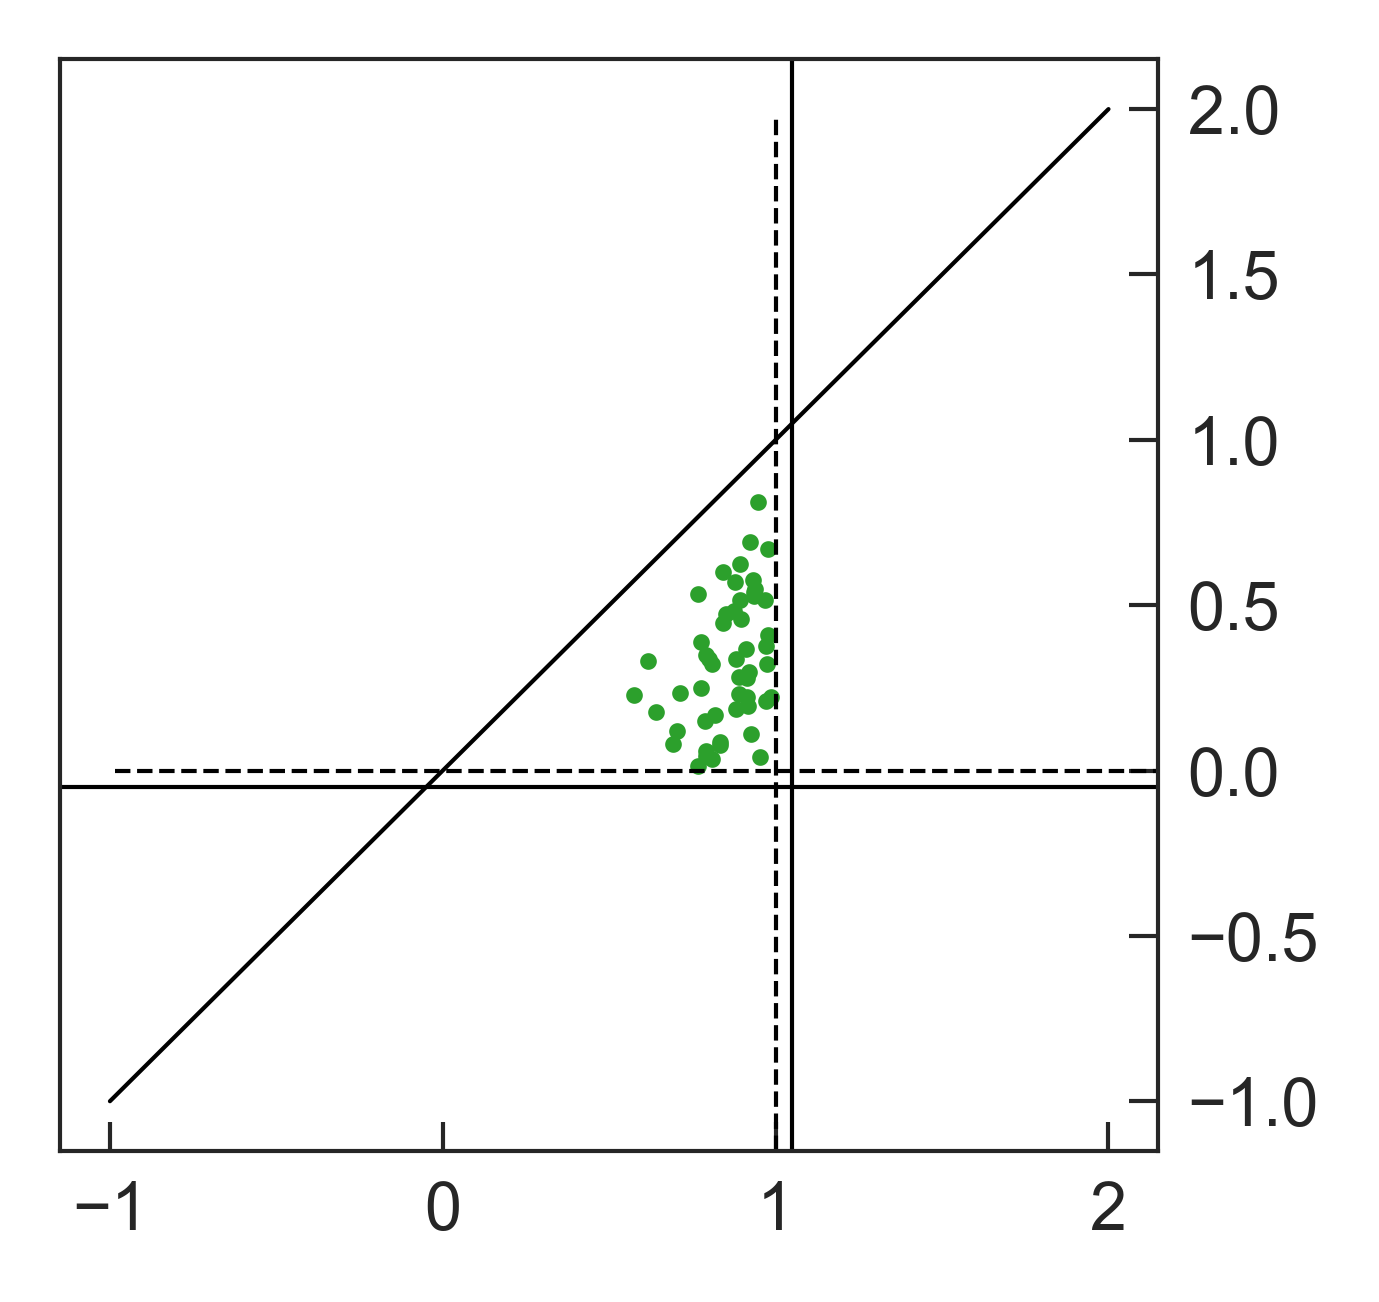

In [11]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data
degList=np.zeros(43)
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):

    Null_model_rep=1



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        IDX_list = Syn_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        data1=[]
        data2=[]
        data3=[]
        data4=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(Null_model_rep):
                c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=0.25
                moc_c2=0.25
                while np.sum(moc_c1)<0.5 or np.sum(moc_c2)<0.5:
                    moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                    moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                    moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                    moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))
                if _==0:
                    u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
                    #a=abs(u/np.sqrt(u*u+v*v))
                    #b=abs(v/np.sqrt(u*u+v*v))
                    #u=a
                    #v=b
                    data1.append(u)
                    data2.append(v)
                u,v,k=metric_VectorDecomposition_onlyPositive(moc_c1,moc_c2,c_mix)
                data3.append(u)
                data4.append(v)
                #data_null_model.append(metric2(moc_c1,moc_c2,c_mix))

        data_null_model = np.array(data_null_model)
        data_null_model = data_null_model.reshape([-1,Null_model_rep])
        #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

       
        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        
        x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
        y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
        print(type_name,np.mean(x*y), np.std(x*y))
        z=x*y
        print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

        scatter(x,x*y,s=1,color=colors[c_i])

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0,  xmin=0.05, xmax=1, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, ymin=0, ymax=0.95, color='k', linestyle='--', linewidth=.5)
        plt.axhline(-0.05, color='k', linestyle='-', linewidth=.5)
        plt.axvline(1.05, color='k', linestyle='-', linewidth=.5)

        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        #plt.xlabel('Persistency')
        #plt.ylabel('Assymetricity')
        #plt.title(f'{type_name}')

        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{type_name}_style1.svg',bbox_inches='tight')




        

mask